In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel("data/heart_disease.xlsx", sheet_name="Heart_disease")

# Display the first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [4]:
# Check dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    str    
 2   cp        908 non-null    str    
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    str    
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    str    
 11  thal      908 non-null    str    
 12  num       908 non-null    int64  
dtypes: float64(1), int64(5), object(2), str(5)
memory usage: 92.3+ KB


In [5]:
# Check missing values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [6]:
# Fill missing values in oldpeak with the median
df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].median())

# Check missing values again
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(1)

In [8]:
# Statistical summary of numerical columns
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.864537,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.060433,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [9]:
# Check unique values in categorical columns
categorical_columns = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


sex:
sex
Male      718
Female    190
Name: count, dtype: int64

cp:
cp
asymptomatic       495
non-anginal        203
atypical angina    165
typical angina      45
Name: count, dtype: int64

fbs:
fbs
False    680
True     139
TRUE      46
FALSE     43
Name: count, dtype: int64

restecg:
restecg
normal              542
lv hypertrophy      187
st-t abnormality    179
Name: count, dtype: int64

exang:
exang
False    516
True     337
TURE      36
FALSE     19
Name: count, dtype: int64

slope:
slope
flat           453
upsloping      298
downsloping    157
Name: count, dtype: int64

thal:
thal
reversable defect    372
normal               339
fixed defect         197
Name: count, dtype: int64


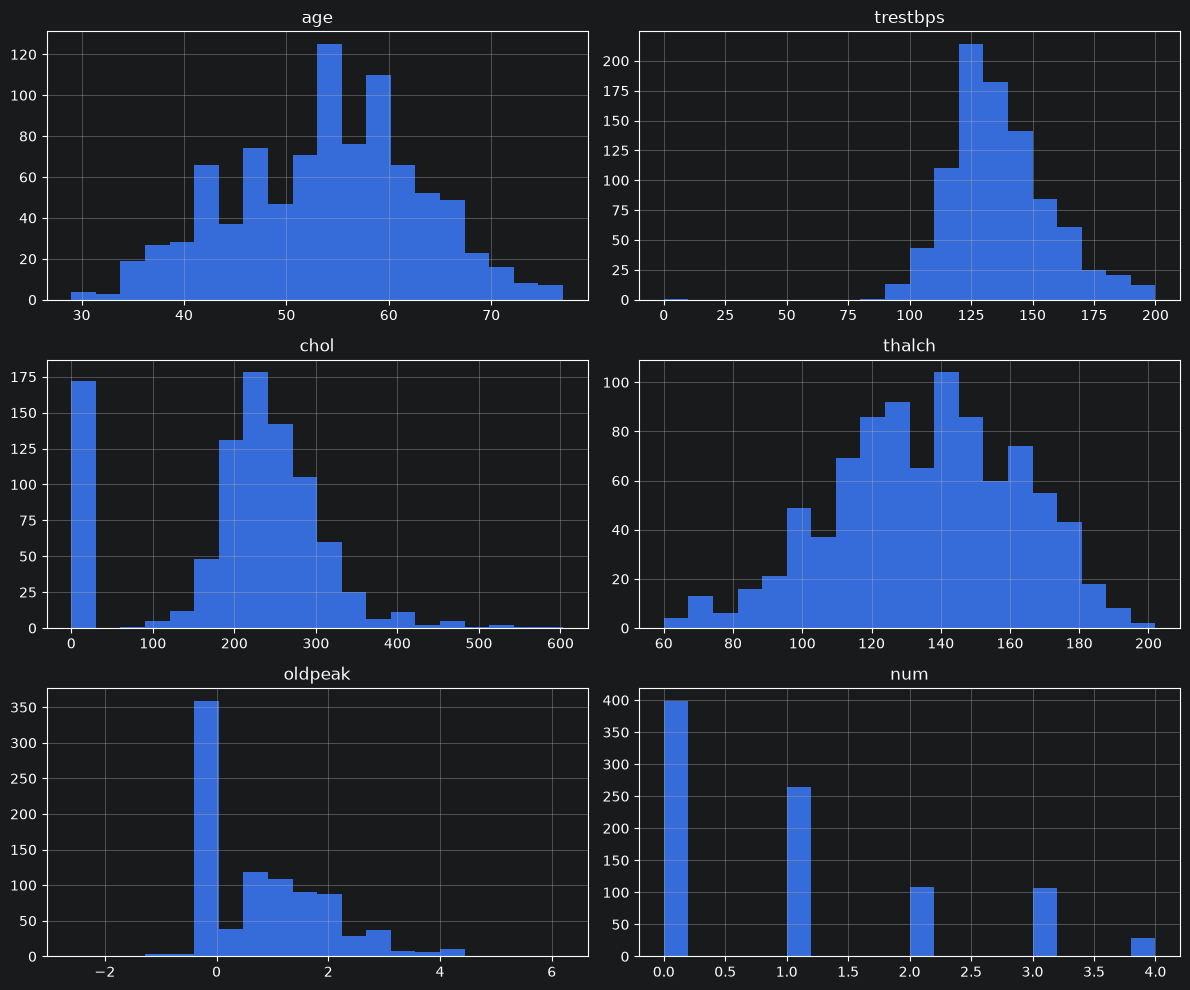

In [10]:
import matplotlib.pyplot as plt

# Plot histograms for numerical columns
df.hist(figsize=(12, 10), bins=20)

plt.tight_layout()
plt.show()

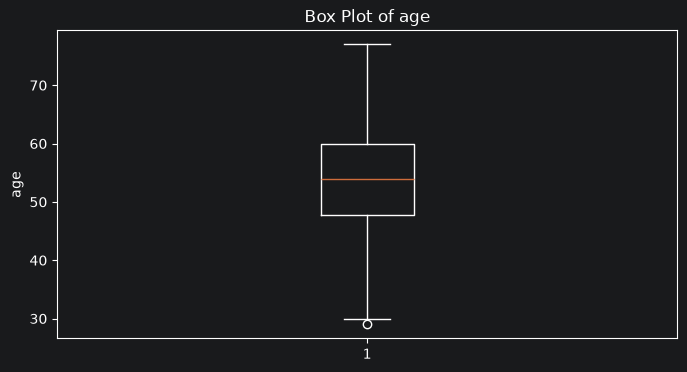

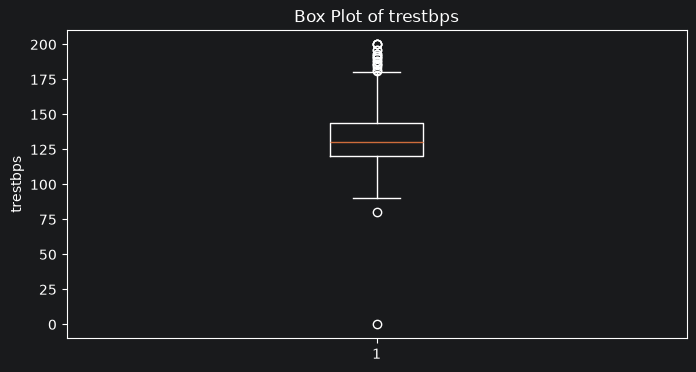

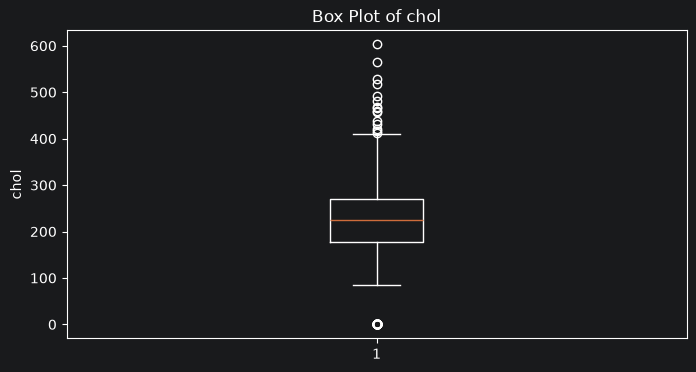

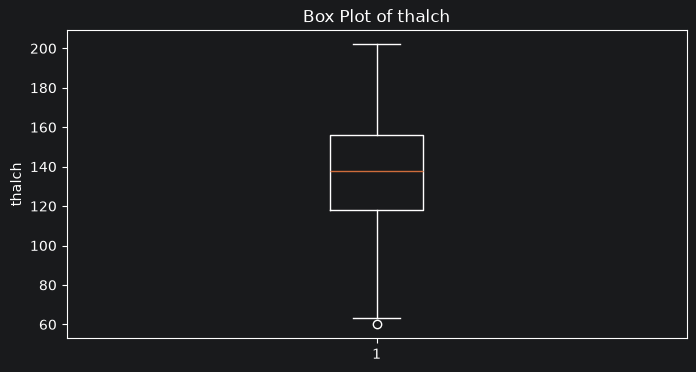

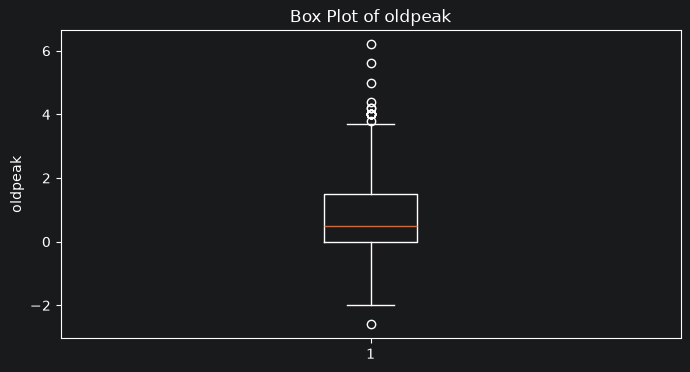

In [11]:
# Box plots for numerical columns
numerical_columns = ["age", "trestbps", "chol", "thalch", "oldpeak"]

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column])
    plt.title(f"Box Plot of {column}")
    plt.ylabel(column)
    plt.show()

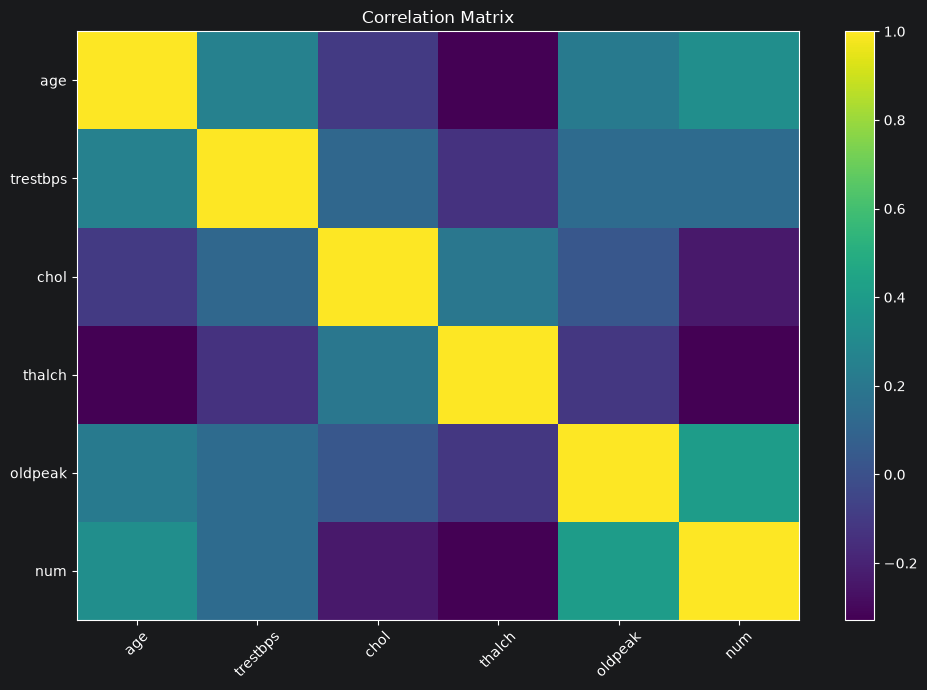

In [12]:
# Correlation matrix for numerical columns
correlation_matrix = df[numerical_columns + ["num"]].corr()

plt.figure(figsize=(10, 7))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
# Separate features and target
X = df.drop("num", axis=1)
y = df["num"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (908, 12)
Target shape: (908,)


In [14]:
# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Display the shape after encoding
print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)

# Display the encoded columns
print("\nEncoded columns:")
print(X_encoded.columns)

Shape before encoding: (908, 12)
Shape after encoding: (908, 21)

Encoded columns:
Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex_Male',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True',
       'fbs_FALSE', 'fbs_TRUE', 'restecg_normal', 'restecg_st-t abnormality',
       'exang_True', 'exang_FALSE', 'exang_TURE', 'slope_flat',
       'slope_upsloping', 'thal_normal', 'thal_reversable defect'],
      dtype='str')


In [16]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (726, 21)
Testing features: (182, 21)
Training target: (726,)
Testing target: (182,)


In [17]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [18]:
# Make predictions on the test data
y_pred = dt_model.predict(X_test)

print("Predictions generated successfully.")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully.
First 10 predictions: [3 0 1 3 0 3 1 0 0 1]


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.45604395604395603
Precision: 0.458580187928014
Recall   : 0.45604395604395603
F1-Score : 0.456456875913668


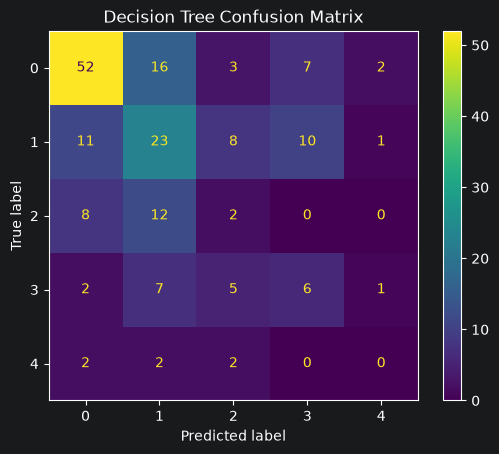

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt_model.classes_
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import classification_report

# Generate classification report
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.69      0.65      0.67        80
           1       0.38      0.43      0.41        53
           2       0.10      0.09      0.10        22
           3       0.26      0.29      0.27        21
           4       0.00      0.00      0.00         6

    accuracy                           0.46       182
   macro avg       0.29      0.29      0.29       182
weighted avg       0.46      0.46      0.46       182



In [22]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters to test
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train with hyperparameter tuning
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.5729617383089277


In [23]:
# Create the optimized Decision Tree
best_dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train the optimized model
best_dt_model.fit(X_train, y_train)

print("Optimized Decision Tree trained successfully.")

Optimized Decision Tree trained successfully.


In [24]:
# Make predictions using the optimized model
y_pred_best = best_dt_model.predict(X_test)

# Calculate evaluation metrics
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(
    y_test, y_pred_best, average="weighted", zero_division=0
)
recall_best = recall_score(
    y_test, y_pred_best, average="weighted", zero_division=0
)
f1_best = f1_score(
    y_test, y_pred_best, average="weighted", zero_division=0
)

print("Optimized Decision Tree Performance")
print("-----------------------------------")
print("Accuracy :", accuracy_best)
print("Precision:", precision_best)
print("Recall   :", recall_best)
print("F1-Score :", f1_best)

Optimized Decision Tree Performance
-----------------------------------
Accuracy : 0.532967032967033
Precision: 0.5421004434162329
Recall   : 0.532967032967033
F1-Score : 0.48182389039531903


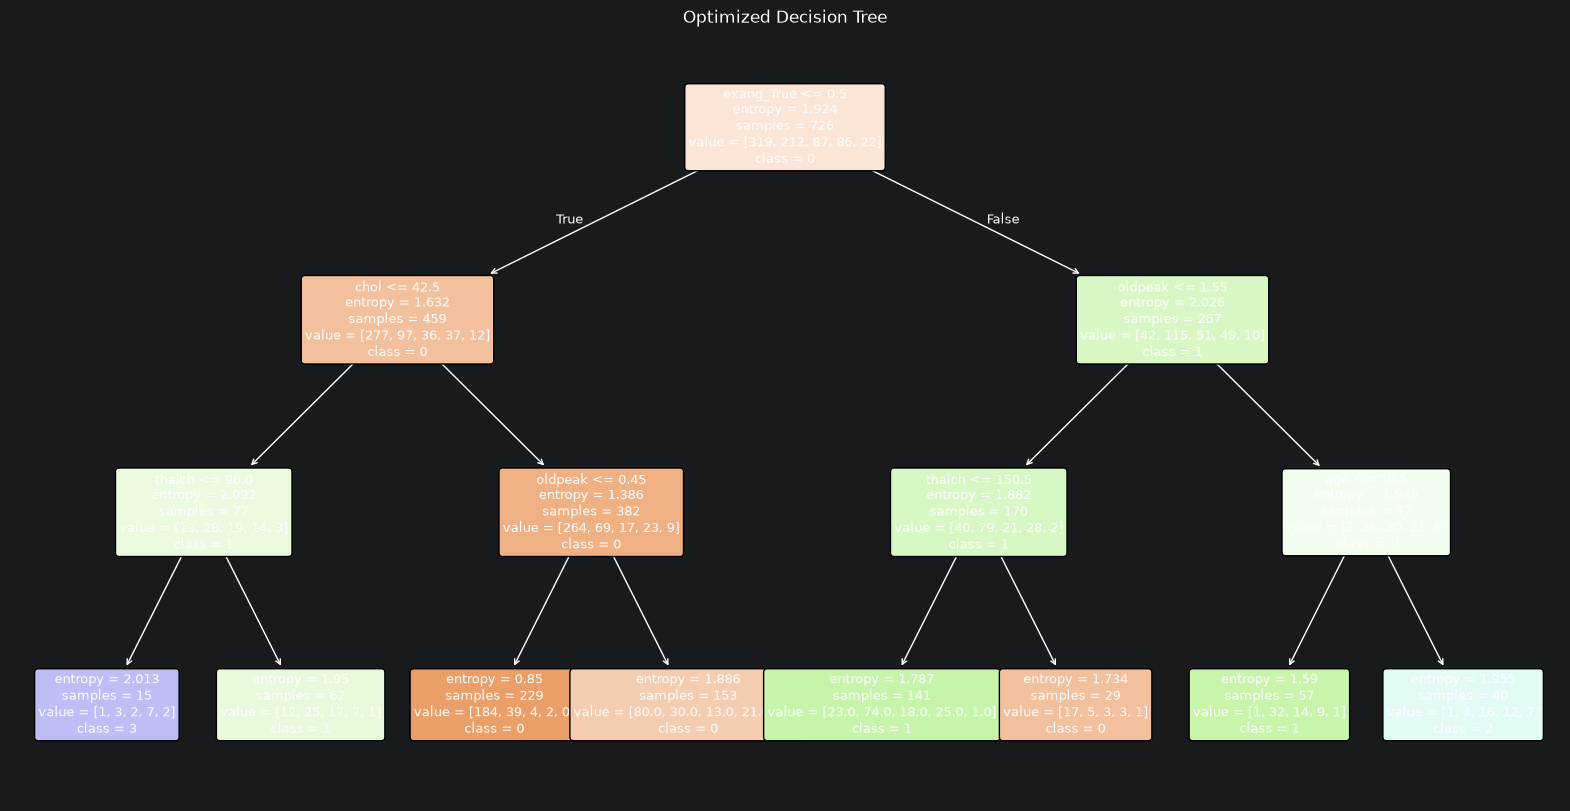

In [25]:
from sklearn.tree import plot_tree

# Visualize the optimized Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    best_dt_model,
    feature_names=X_train.columns,
    class_names=[str(c) for c in best_dt_model.classes_],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Optimized Decision Tree")
plt.show()

In [26]:
# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_dt_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
print(feature_importance)

                     Feature  Importance
14                exang_True    0.367091
4                    oldpeak    0.269055
2                       chol    0.201347
3                     thalch    0.094635
0                        age    0.067872
12            restecg_normal    0.000000
19               thal_normal    0.000000
18           slope_upsloping    0.000000
17                slope_flat    0.000000
16                exang_TURE    0.000000
15               exang_FALSE    0.000000
13  restecg_st-t abnormality    0.000000
10                 fbs_FALSE    0.000000
11                  fbs_TRUE    0.000000
1                   trestbps    0.000000
9                   fbs_True    0.000000
8          cp_typical angina    0.000000
7             cp_non-anginal    0.000000
6         cp_atypical angina    0.000000
5                   sex_Male    0.000000
20    thal_reversable defect    0.000000


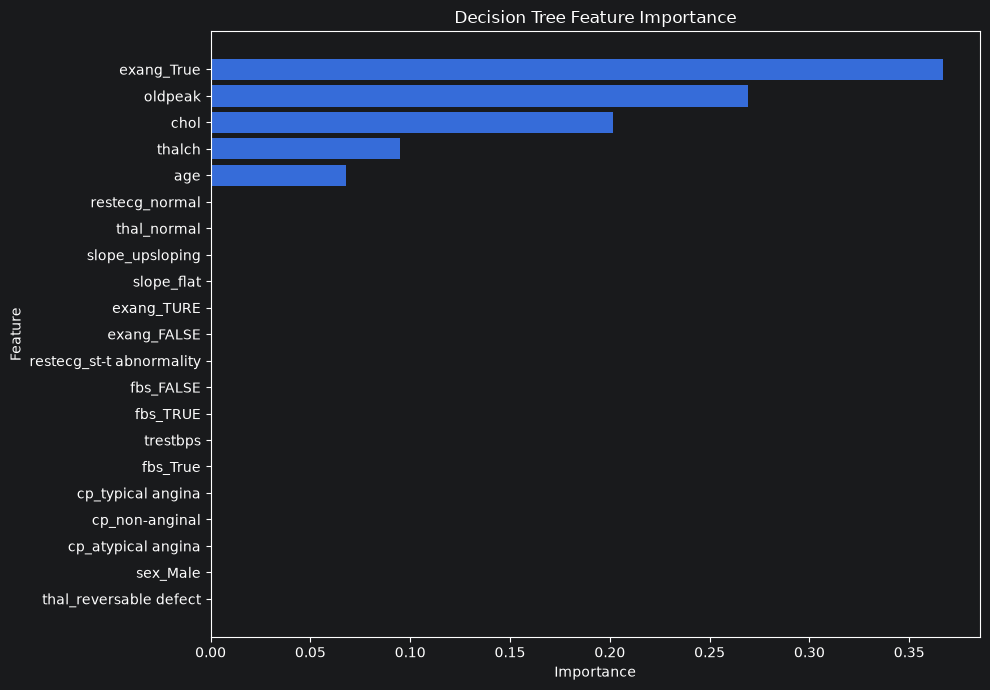

In [27]:
# Plot feature importance
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import roc_auc_score

# Get probability predictions
y_prob = best_dt_model.predict_proba(X_test)

# Calculate multiclass ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7300865559257635


### Interview Question 1

Common hyperparameters of Decision Tree models include:

- **max_depth:** Controls the maximum depth of the tree. A smaller value can reduce overfitting, while a larger value can make the model more complex and may cause overfitting.

- **min_samples_split:** Specifies the minimum number of samples required to split an internal node. Increasing this value makes the tree simpler and can reduce overfitting.

- **min_samples_leaf:** Specifies the minimum number of samples that must be present in a leaf node. A higher value creates larger leaf nodes and can improve generalization.

- **criterion:** Determines the function used to measure the quality of a split. Common options include `gini` and `entropy`.

- **max_features:** Controls the number of features considered when looking for the best split. Limiting the number of features can reduce model complexity.

Hyperparameters control the complexity of the Decision Tree and therefore affect the balance between underfitting and overfitting.